In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

## 1. Distribuciones Globales

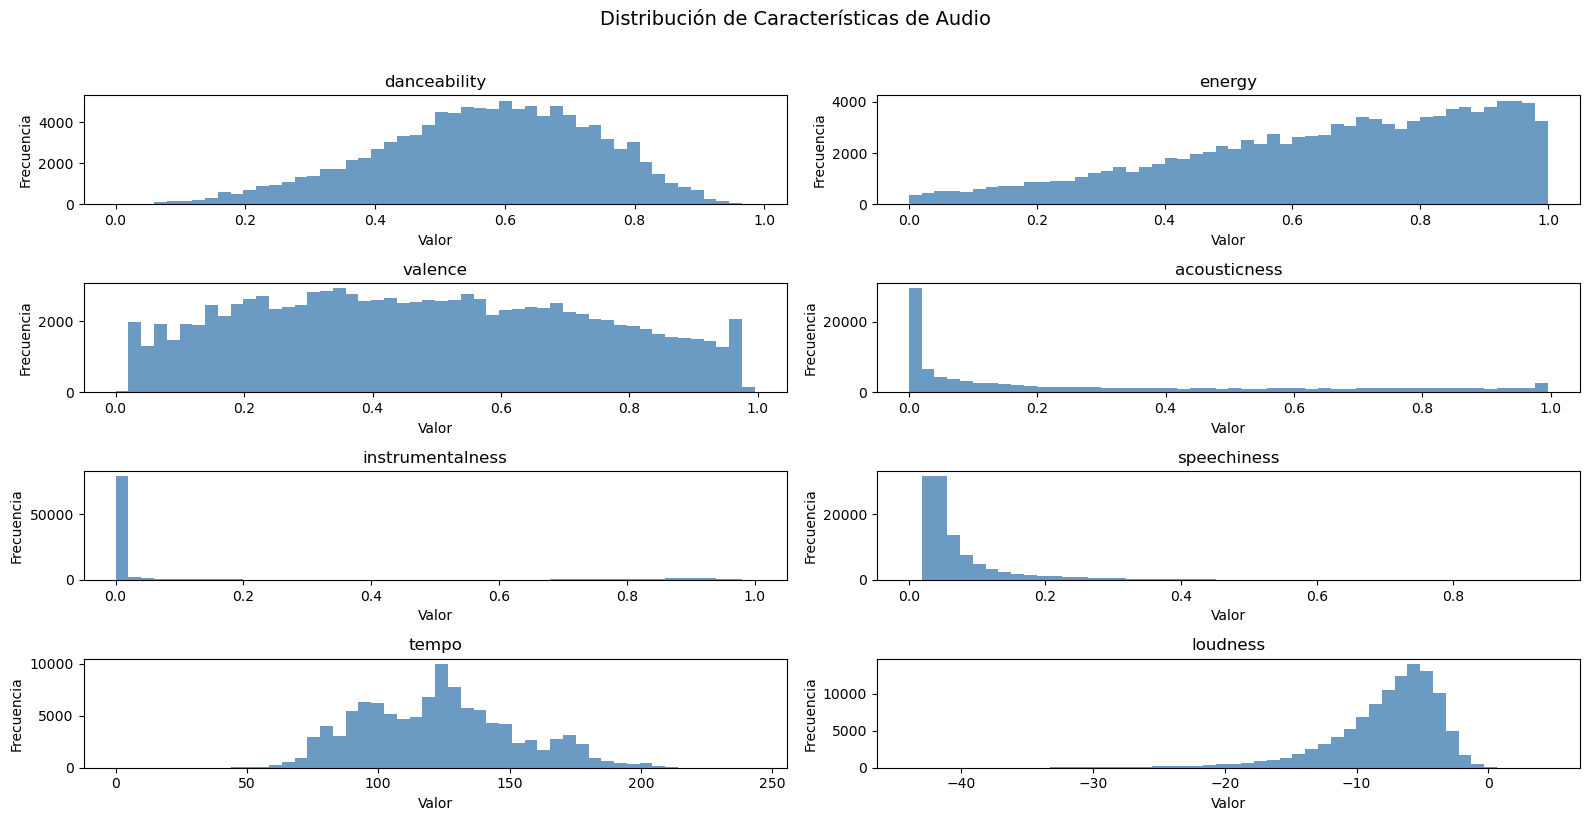

In [ ]:

df = pd.read_csv("D:\PROYECTOS\SPOTIFY-ANALYSIS\data\dataset_limpio.csv")

# características del audio que nos importan
audio_features = ['danceability', 'energy', 'valence',
                  'acousticness','instrumentalness',
                   'speechiness', 'tempo','loudness']

# distribución de cada característica
fig, axes = plt.subplots(4, 2, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins = 50, color = 'steelblue', edgecolor = 'none', alpha = 0.8 )
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Características de Audio', fontsize=14, y = 1.02)
plt.tight_layout()
plt.savefig("../notebooks/img/01_distribuciones.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Variabilidad entre Géneros

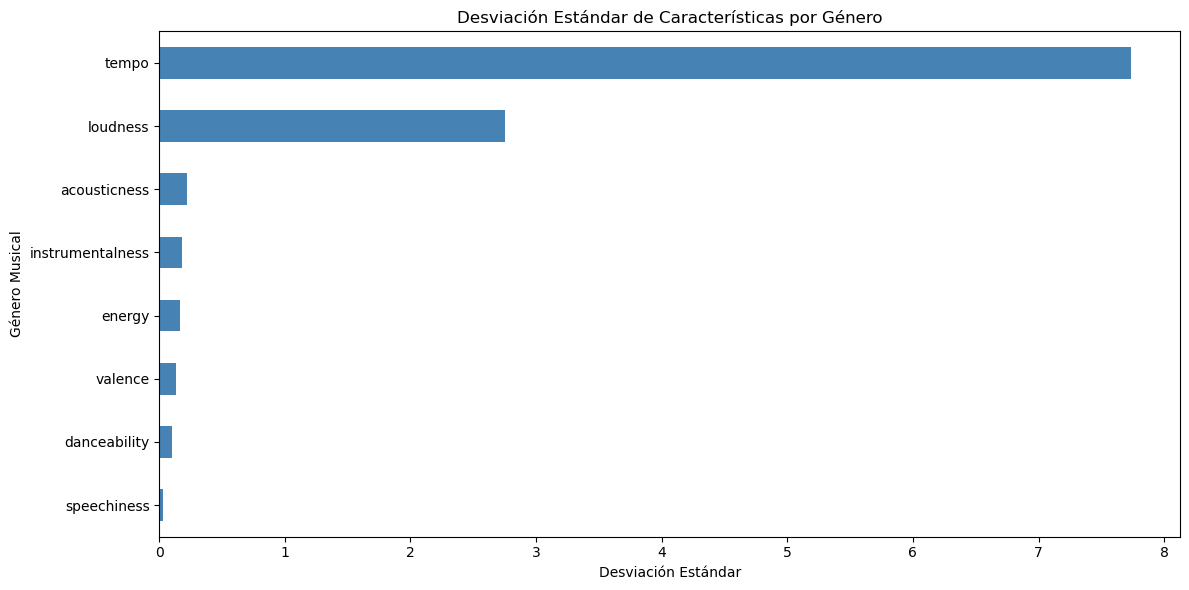

In [13]:
# miramos media de cada característica por género
genero_means = df.groupby('track_genre')[audio_features].mean()

fig, axes = plt.subplots(figsize=(12, 6))
genero_means.std().sort_values().plot(kind='barh', color='steelblue', ax=axes)
plt.title('Desviación Estándar de Características por Género')
plt.xlabel('Desviación Estándar')
plt.ylabel('Género Musical')
plt.tight_layout()
plt.savefig("../notebooks/img/01_desviacion_genero.png", dpi=150, bbox_inches='tight')
plt.show()

El tempo y el loudness son las características que más diferencian a los géneros musicales entre sí, con una desviación estándar muy superior al resto de features.



In [15]:
# sabiendo esto, miramos los 10 generos con mayor y menor tempo
print("TOP 10 Géneros con mayor tempo:")
print(genero_means['tempo'].sort_values(ascending=False).head(10))
print("\nTOP 10 Géneros con menor tempo:")
print(genero_means['tempo'].sort_values(ascending=True).head(10))

TOP 10 Géneros con mayor tempo:
track_genre
drum-and-bass    155.241712
happy            152.908962
hardstyle        146.837452
forro            140.362197
j-idol           136.112004
power-pop        134.651615
dubstep          133.631709
punk             133.600518
trance           133.276726
breakbeat        133.030213
Name: tempo, dtype: float64

TOP 10 Géneros con menor tempo:
track_genre
opera         105.584558
classical     107.949793
romance       109.693052
guitar        112.000239
disney        112.060854
jazz          112.636469
dancehall     112.909984
show-tunes    114.372216
tango         114.554320
soul          114.629169
Name: tempo, dtype: float64


## 3. Heatmap

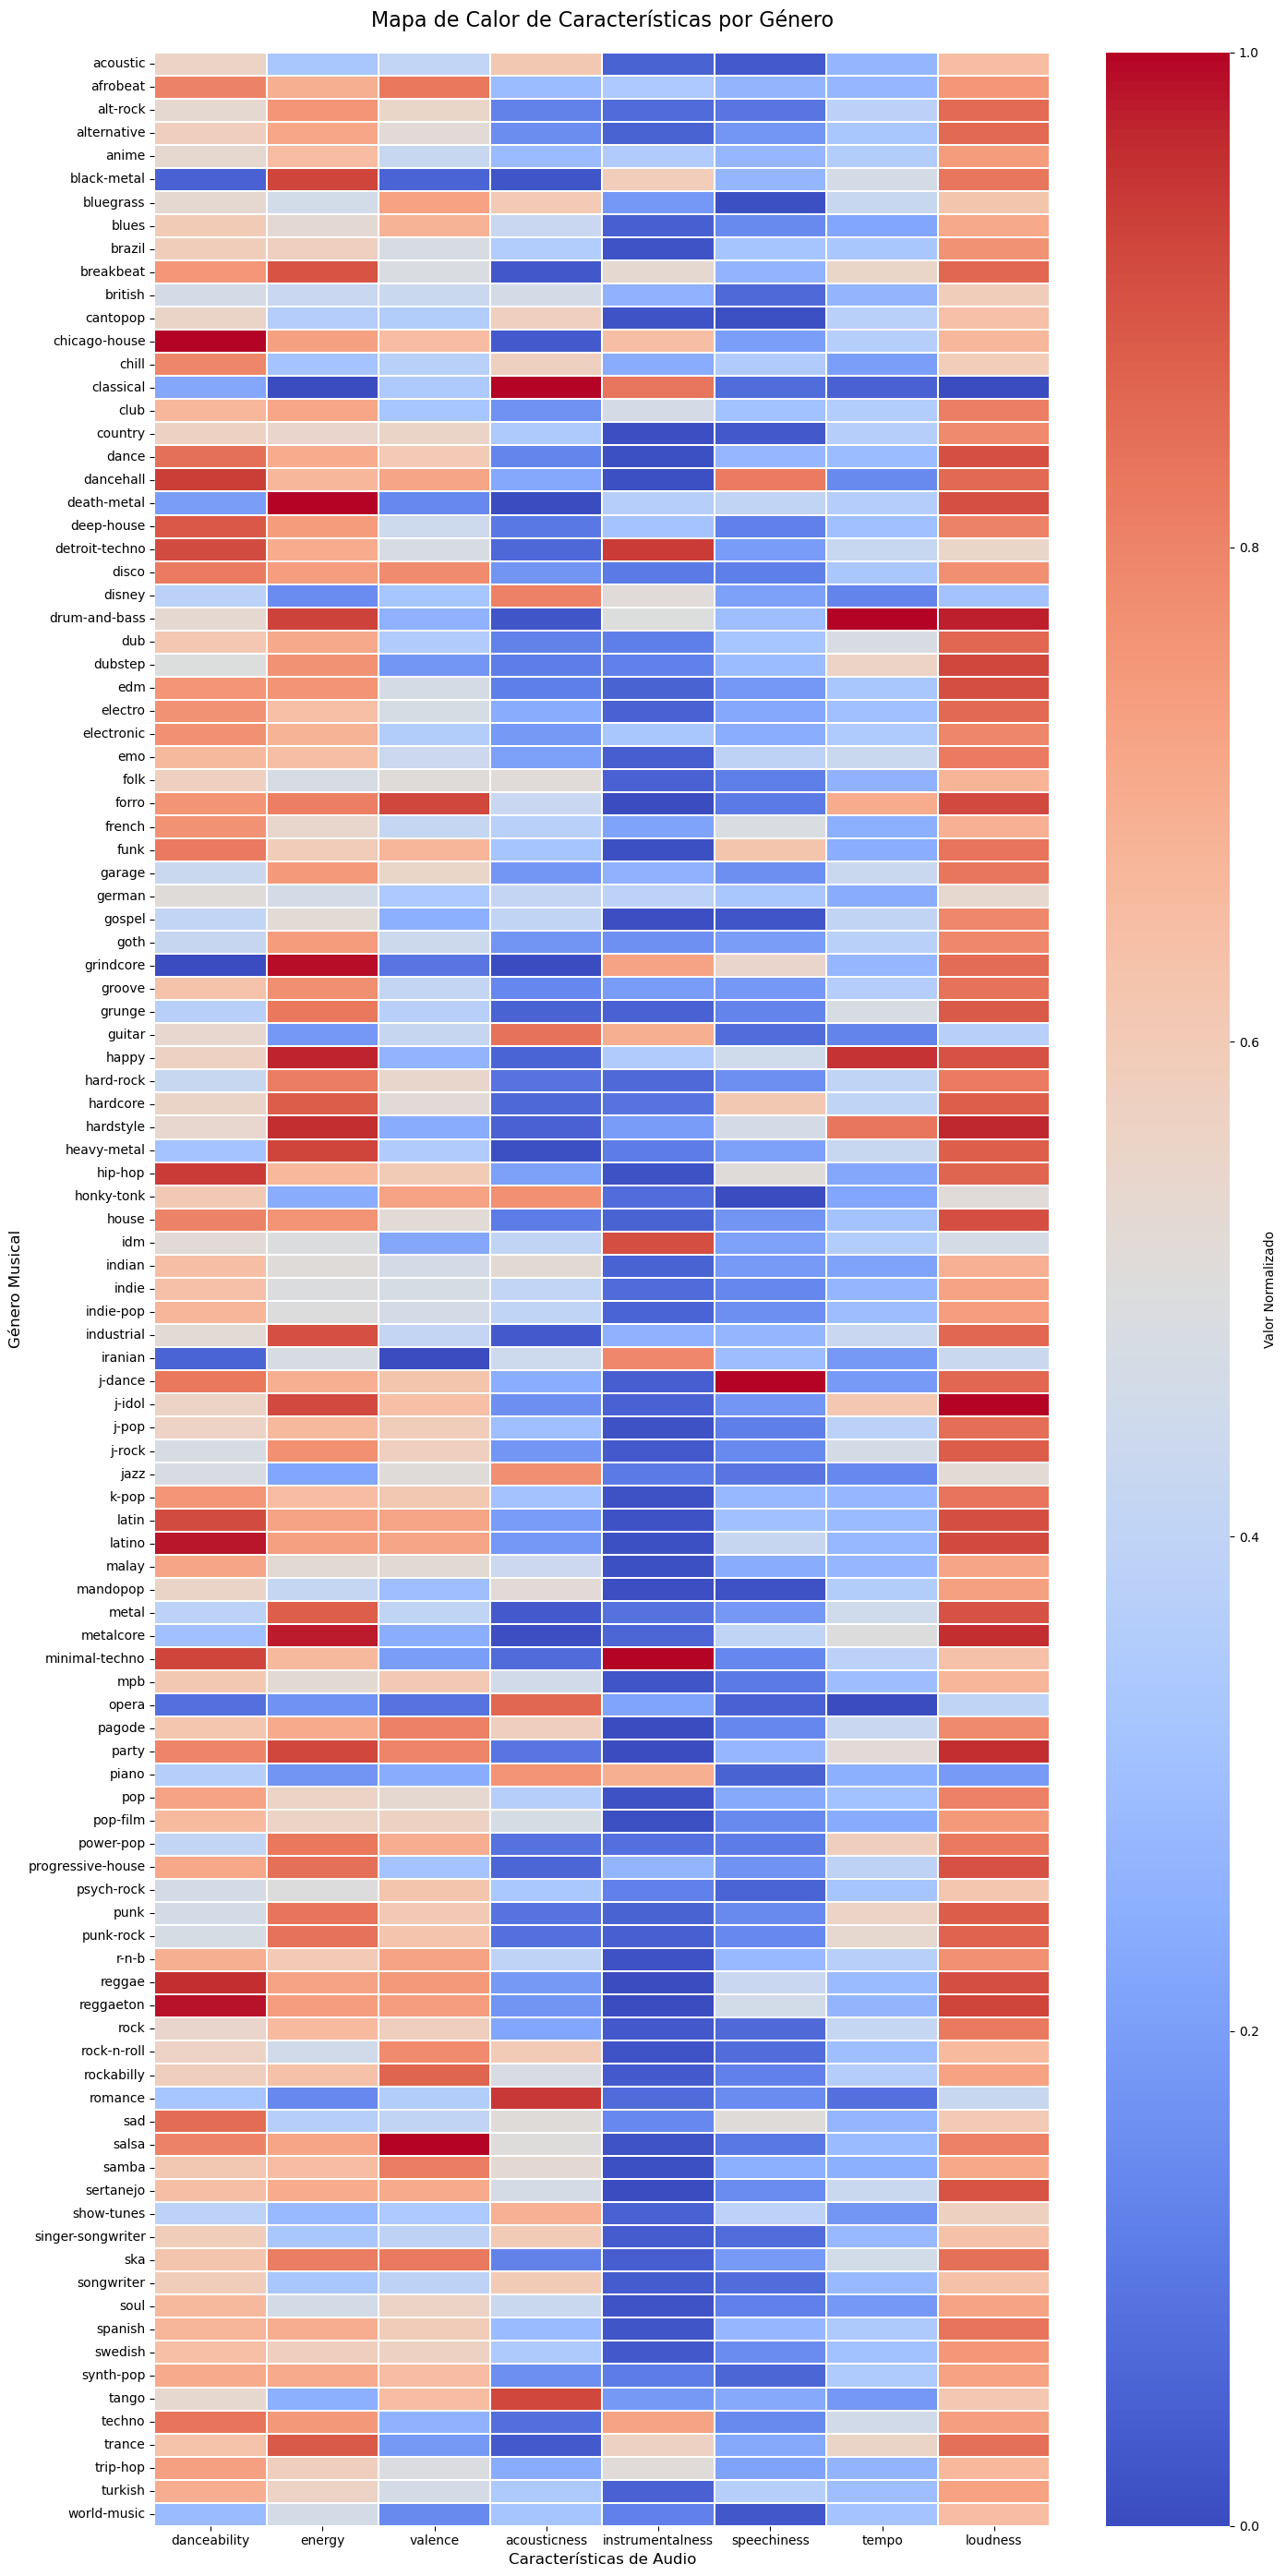

In [18]:
# Normalizamos las features para que estén en la misma escala (0-1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
genero_means_scaled = pd.DataFrame(
    scaler.fit_transform(genero_means),
    index = genero_means.index,
    columns = genero_means.columns
)

# Mapa de calor de las características por género
fig , ax = plt.subplots(figsize=(14 , 28))
sns.heatmap(
    genero_means_scaled,
    cmap='coolwarm',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Valor Normalizado'}
    
)

ax.set_title('Mapa de Calor de Características por Género', fontsize=16, pad =20)
ax.set_xlabel('Características de Audio', fontsize=12)
ax.set_ylabel('Género Musical', fontsize=12)
plt.tight_layout()
plt.savefig("../notebooks/img/01_heatmap_genero.png", dpi=150, bbox_inches='tight')
plt.show()

## Observaciones HeatMap

* Minimal-techno: instrumentalness muy alta, música de máquinas pura
* Hip-hop: speechiness alta, el rap es palabra ante todo
* Reggaeton: danceability y loudness altas, hecho para bailar y sonar alto
* Metalcore: energy altísima, danceability baja, intensidad sin ritmo bailable
* Classical vs Black-metal son los dos extremos opuestos perfectos del dataset. Classical tiene acousticness e instrumentalness altas con energy baja. Black-metal tiene energy y loudness altísimas con acousticness casi nula. Son los dos polos del universo musical y los datos lo confirman
* Iranian y Turkish tienen un patrón muy similar entre sí, con valence alta y danceability moderada. Sugiere que la música de Oriente Medio tiende a ser más alegre emocionalmente de lo que la gente occidental imagina.

## 4. Comparativa Radar

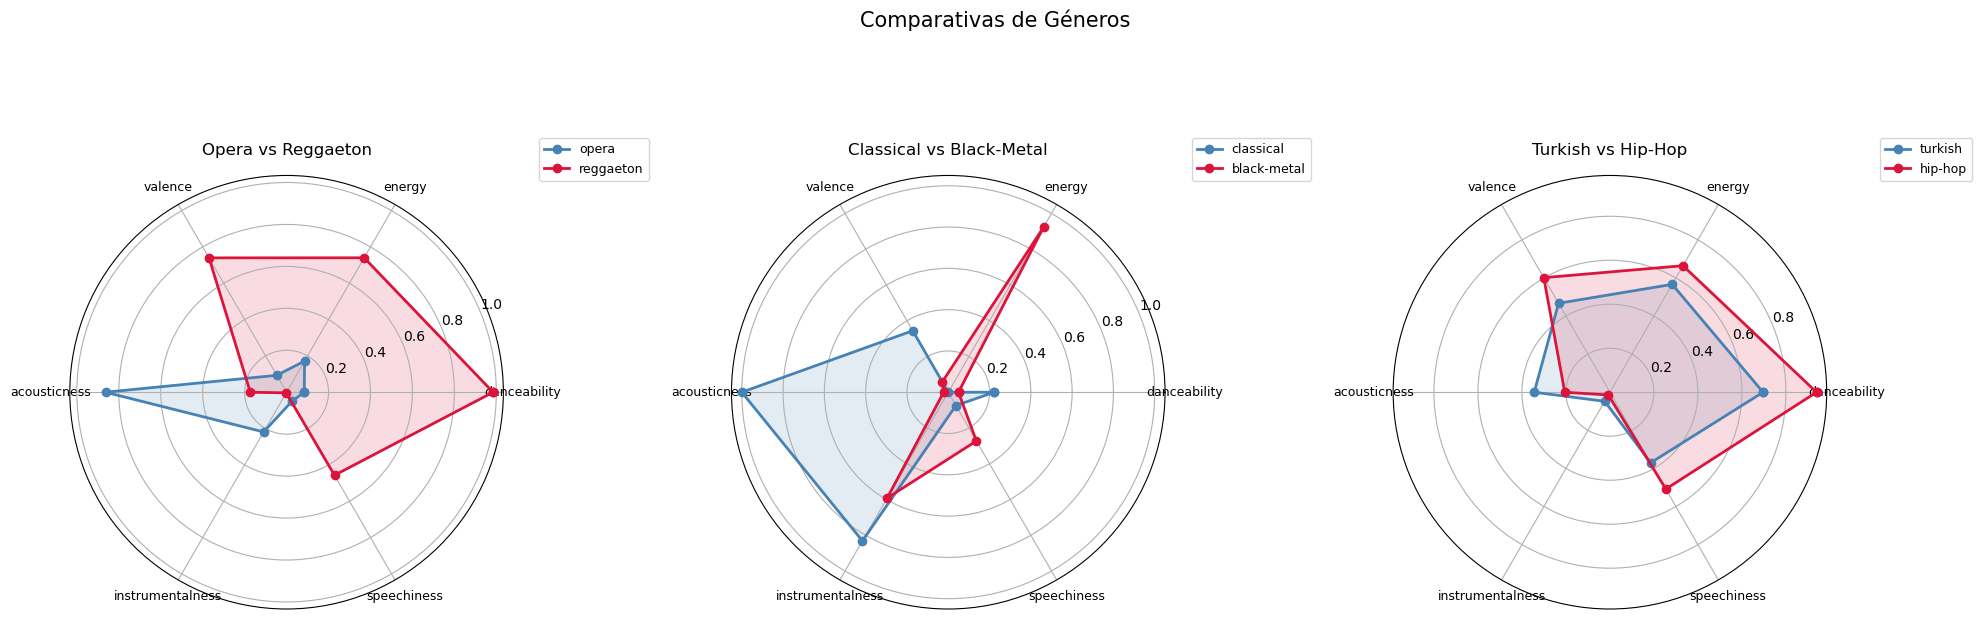

In [27]:
generos_a_comparar = ['classical','black-metal', 'reggaeton',
                      'opera','turkish','hip-hop']

caracteristicas_a_comparar = ['danceability', 'energy', 'valence',
                            'acousticness','instrumentalness','speechiness']

radar_data = genero_means_scaled.loc[generos_a_comparar, caracteristicas_a_comparar]

# configuramos el radar
def comparacion_radar(generos, titulo, filename, features=caracteristicas_a_comparar):
    angulos = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    angulos += angulos[:1]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 7), subplot_kw=dict(polar=True))

    comparisons = [
        (['opera', 'reggaeton'], 'Opera vs Reggaeton'),
        (['classical', 'black-metal'], 'Classical vs Black-Metal'),
        (['turkish', 'hip-hop'], 'Turkish vs Hip-Hop')
    ]

    colores = ['steelblue', 'crimson']

    for ax, (generos, titulo) in zip(axes, comparisons):
        angles = np.linspace(0, 2*np.pi, len(caracteristicas_a_comparar), endpoint=False).tolist()
        angles += angles[:1]
        
        for i, genre in enumerate(generos):
            values = genero_means_scaled.loc[genre, caracteristicas_a_comparar].tolist()
            values += values[:1]
            ax.plot(angles, values, 'o-', linewidth=2, label=genre, color=colores[i])
            ax.fill(angles, values, alpha=0.15, color=colores[i])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(caracteristicas_a_comparar, fontsize=9)
        ax.set_title(titulo, fontsize=12, pad=15)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

    plt.suptitle('Comparativas de Géneros', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig("../notebooks/img/05_radares_comparativas.png", dpi=150, bbox_inches='tight')
    plt.show()

# Primero el conjunto
comparacion_radar(
    ['classical', 'black-metal', 'reggaeton', 'opera', 'turkish', 'hip-hop'],
    'Comparativa General de Géneros',
    '04_radar_general'
)

# Luego los individuales
#comparacion_radar(['opera', 'reggaeton'], 'Opera vs Reggaeton', '05_radar_opera_reggaeton')
#comparacion_radar(['classical', 'black-metal'], 'Classical vs Black-Metal', '06_radar_classical_metal')
#comparacion_radar(['turkish', 'hip-hop'], 'Turkish vs Hip-Hop', '07_radar_turkish_hiphop')

Dos culturas musicales completamente distintas, una de Oriente Medio y otra nacida en el Bronx de Nueva York, que convergen en un perfil sonoro parecido. Eso dice algo sobre los universales de la música popular: independientemente del origen cultural, la música que conecta con la gente tiende a ser bailable y energética.